In [1]:
using QuadGK,LaTeXStrings,LinearAlgebra,BenchmarkTools;
using Plots,CSV,DataFrames;
import ForwardDiff;
import NLsolve,Roots;
import Optim;

In [2]:
pyplot(frame=:box, minorticks=5, size=(400,300), fontfamily="serif",titlefontsize=11
    ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);

In [3]:
include("./libs/constants.jl");
include("./libs/pwa.jl");
include("./libs/potentials.jl");

In [4]:
λf(x, y, z) = x^2 + y^2 + z^2 - 2 * x * y - 2 * x * z - 2 * y * z
q0f(E, m1, m2, m3, m4) = abs(m3^2 - m4^2 - m1^2 + m2^2) / (2 * E)
μf(m1, m2) = m1 * m2 / (m1 + m2)

# redefine sqrt so that its cut is along the positive x axis
function xsqrt(x)
    imag(x) >=0 ? sqrt(x+0im) : -sqrt(x-0im)
end

xsqrt (generic function with 1 method)

# $1-VG$

In [5]:
μT=mDn*mDsc/(mDn+mDsc);
γT=sqrt(2*μT*273*1.0e-6);
println(μT)
println(γT)

0.9674107141493122
0.022982738085909702


In [6]:
f_CT(Λ;μ=μT,γ=γT)=μ*γ/π^2*(Λ/γ-atan(Λ/γ))
f_E1(Λ,m;μ=μT,γ=γT)=μ/π^2*(m*atan(Λ/m)-γ*atan(Λ/γ))/(m^2-γ^2)
f_M1(Λ,m;μ=μT,γ=γT)=μ/π^2*(Λ*(m^2-γ^2)-m^3*atan(Λ/m)+γ^3*atan(Λ/γ))/(m^2-γ^2)

f_M1 (generic function with 1 method)

In [7]:
gr()

Plots.GRBackend()

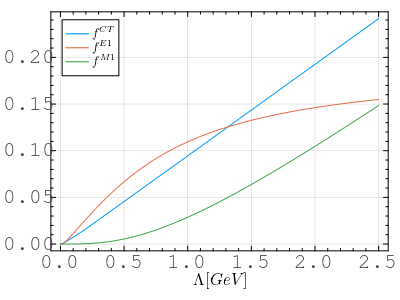

GKS: could not find font serif.ttf


In [8]:
plot(f_CT,0.0,2.5,label=L"f^{CT}",xlabel=L"\Lambda[GeV]")
plot!(x->f_E1(x,mρn),0.0,2.5,label=L"f^{E1}")
plot!(x->f_M1(x,mρn),0.0,2.5,label=L"f^{M1}")
# savefig("./images/review_ffunctions.pdf")
current()

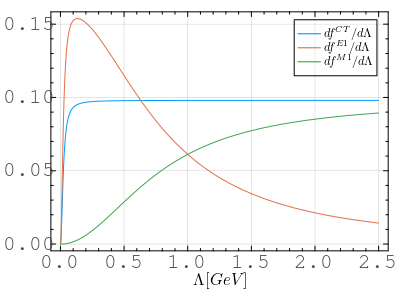

In [9]:
plot(x->ForwardDiff.derivative(x->f_CT(x),x),0.0,2.5,label=L"df^{CT}/d\Lambda",xlabel=L"\Lambda[GeV]")
plot!(x->ForwardDiff.derivative(x->f_E1(x,mρn),x),0.0,2.5,label=L"df^{E1}/d\Lambda")
plot!(x->ForwardDiff.derivative(x->f_M1(x,mρn),x),0.0,2.5,label=L"df^{M1}/d\Lambda")
# savefig("./images/review_dffunctions.pdf")
current()

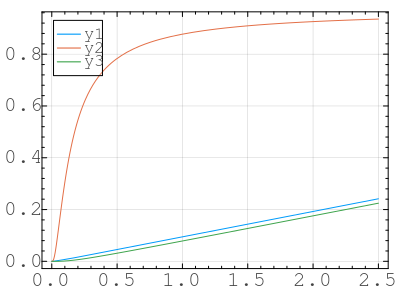

In [10]:
plot(f_CT,0.0,2.5)
plot!(x->f_E1(x,mπn),0.0,2.5)
plot!(x->f_M1(x,mπn),0.0,2.5)

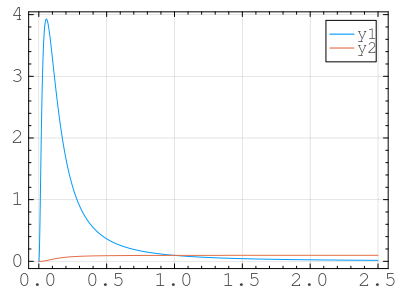

In [11]:
plot(x->ForwardDiff.derivative(x->f_E1(x,mπn),x),0.0,2.5)
plot!(x->ForwardDiff.derivative(x->f_M1(x,mπn),x),0.0,2.5)

# Parameter dependence in the lineshape fitting

In [5]:
df_fitting_scheme1=DataFrame(CSV.File("./output/review_lamv_Cv_scheme1.csv"));
df_fitting_scheme2=DataFrame(CSV.File("./output/review_lamv_Cv_schemeII.csv"));
df_fitting_scheme3=DataFrame(CSV.File("./output/review_lamv_Cv_scheme3.csv"));

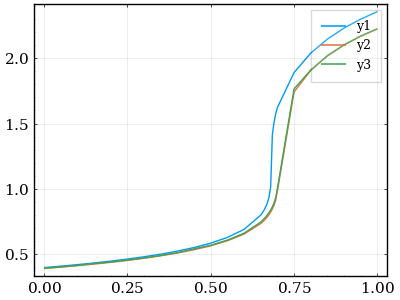

In [7]:
plot(df_fitting_scheme1.Cv,df_fitting_scheme1.lam)
plot!(df_fitting_scheme2.Cv,df_fitting_scheme2.lam)
plot!(df_fitting_scheme3.Cv,df_fitting_scheme3.lam)

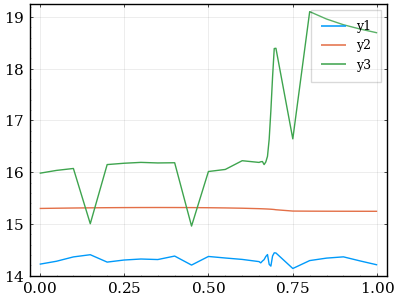

In [8]:
plot(df_fitting_scheme1.Cv,df_fitting_scheme1.chisq)
plot!(df_fitting_scheme2.Cv,df_fitting_scheme2.chisq)
plot!(df_fitting_scheme3.Cv,df_fitting_scheme3.chisq)

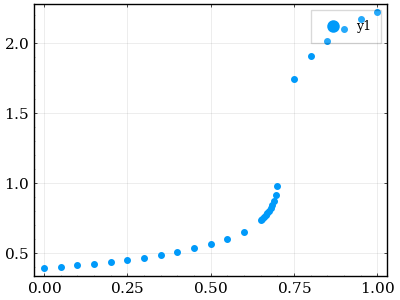

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [11]:
plot()
# scatter!(df_fitting_scheme1.Cv,df_fitting_scheme1.lam)
scatter!(df_fitting_scheme2.Cv,df_fitting_scheme2.lam)
# scatter!(df_fitting_scheme3.Cv,df_fitting_scheme3.lam)